### MNIST and Fashion MNIST datasets 

In [1]:
# Libraries
import numpy as np
import tensorflow as tf
import cv2
import pandas as pd
import os
import pywt
import logging
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import classification_report, confusion_matrix
from scipy.fftpack import fft2, fftshift
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [2]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("MNIST dataset downloaded successfully!")

MNIST dataset downloaded successfully!


In [3]:
# Get path to the MNIST dataset
mnist_path = os.path.expanduser('~/.keras/datasets/mnist.npz')
print(f"MNIST dataset is stored at: {mnist_path}")

MNIST dataset is stored at: C:\Users\klnde/.keras/datasets/mnist.npz


In [4]:
# Shape of the training and testing data
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

# Unique classes and their count
num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")

Training data shape: (60000, 28, 28), Training labels shape: (60000,)
Testing data shape: (10000, 28, 28), Testing labels shape: (10000,)
Number of classes: 10


### The MNIST dataset is saved as mnist.npz, a compressed NumPy format. To load and inspect the content, run:

In [5]:
# Load the MNIST dataset from the .npz file
data = np.load(mnist_path)

# List all available keys (arrays) in the file
print(data.files)

# Extract arrays if needed
X_train_npz, y_train_npz = data['x_train'], data['y_train']
X_test_npz, y_test_npz = data['x_test'], data['y_test']

print("Loaded successfully from .npz!")

['x_test', 'x_train', 'y_train', 'y_test']
Loaded successfully from .npz!


In [6]:
# Unique class labels
unique_classes = np.unique(y_train)
print(f"Class labels: {unique_classes}")

# Distribution of classes in training and testing data
train_class_counts = pd.Series(y_train).value_counts().sort_index()
test_class_counts = pd.Series(y_test).value_counts().sort_index()

print(f"Class distribution in training data:\n{train_class_counts}")
print(f"Class distribution in testing data:\n{test_class_counts}")

Class labels: [0 1 2 3 4 5 6 7 8 9]
Class distribution in training data:
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
dtype: int64
Class distribution in testing data:
0     980
1    1135
2    1032
3    1010
4     982
5     892
6     958
7    1028
8     974
9    1009
dtype: int64


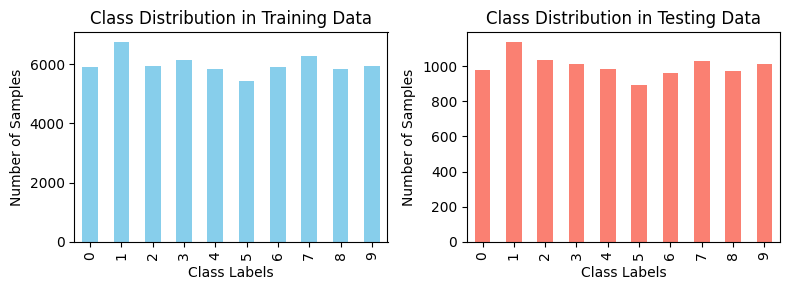

In [7]:
# Plot class distribution for training data
plt.figure(figsize=(8,3))

plt.subplot(1, 2, 1)
train_class_counts.plot(kind='bar', color='skyblue')
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')

# Plot class distribution for testing data
plt.subplot(1, 2, 2)
test_class_counts.plot(kind='bar', color='salmon')
plt.title('Class Distribution in Testing Data')
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')

plt.tight_layout()

# Save the figure BEFORE showing it
plt.savefig("MNIST distribution.png", dpi=300, bbox_inches='tight')

# Now show the plots
plt.show()

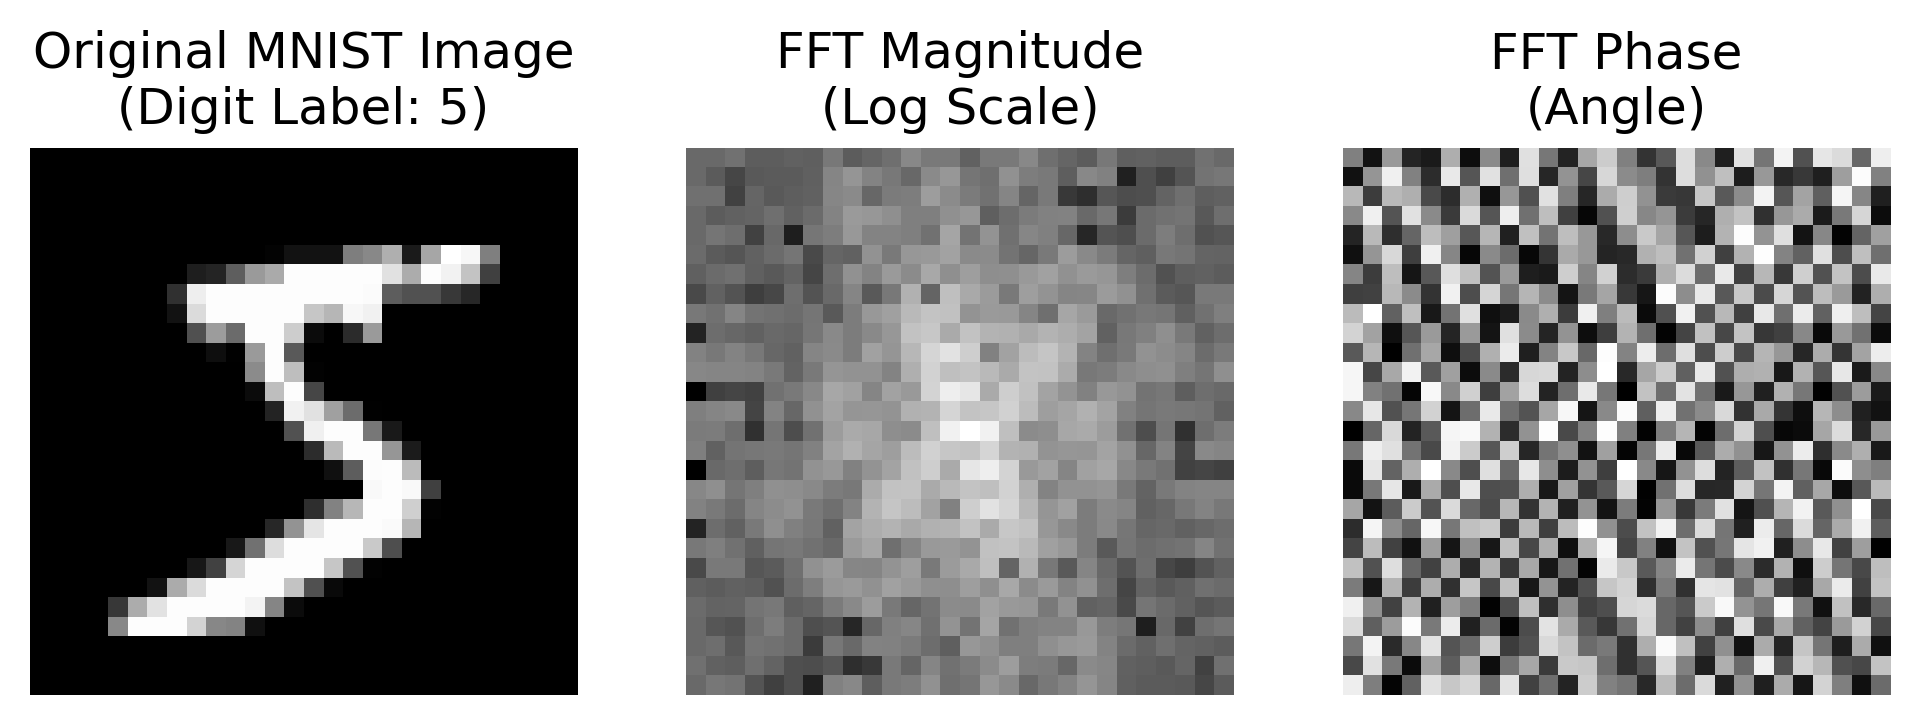

In [8]:
# Pick a sample image (e.g., first image from training set)
sample_img = X_train[0]  # Shape: (28, 28)

# Plot the original image
plt.figure(figsize=(8, 4), dpi=300)

# 1. Original Image
plt.subplot(1, 3, 1)
plt.imshow(sample_img, cmap='gray')
plt.title(f"Original MNIST Image\n(Digit Label: {y_train[0]})", fontsize=12)
plt.axis('off')

# 2. Compute FFT of the sample image
fft_img = fft2(sample_img)
fft_shifted = fftshift(fft_img)  # Shift to center for better visualization

# Get magnitude and phase for visualization
fft_magnitude = np.log1p(np.abs(fft_shifted))  # Log for better scaling
fft_phase = np.angle(fft_shifted)

# 2. FFT Magnitude (Real Part)
plt.subplot(1, 3, 2)
plt.imshow(fft_magnitude, cmap='gray')
plt.title("FFT Magnitude\n(Log Scale)", fontsize=12)
plt.axis('off')

# 3. FFT Phase (Imaginary Part)
plt.subplot(1, 3, 3)
plt.imshow(fft_phase, cmap='gray')
plt.title("FFT Phase\n(Angle)", fontsize=12)
plt.axis('off')

# Define the path where you want to save the figure
save_path = r"C:\Users\klnde\OneDrive\Desktop\Chandrasekhar Marseille\APL Computational Physics\Figures\FFT_results.png"

# Save the figure in the specified path
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Now show the plots
plt.show()

### Wavelet

In [9]:
# Pick a sample image (e.g., digit 5 from training set)
digit_idx = np.where(y_train == 5)[0][0]  # Get index of first digit 5
sample_img = X_train[digit_idx]  # Extract the corresponding image

# Perform 2D Discrete Wavelet Transform (DWT) on the sample image
wavelet = 'haar'  # Use Haar wavelet
level = 1  # Single level decomposition
coeffs2 = pywt.wavedec2(sample_img, wavelet, level=level)

# Extract coefficients
cA, (cH, cV, cD) = coeffs2  # Approximation, Horizontal, Vertical, Diagonal details

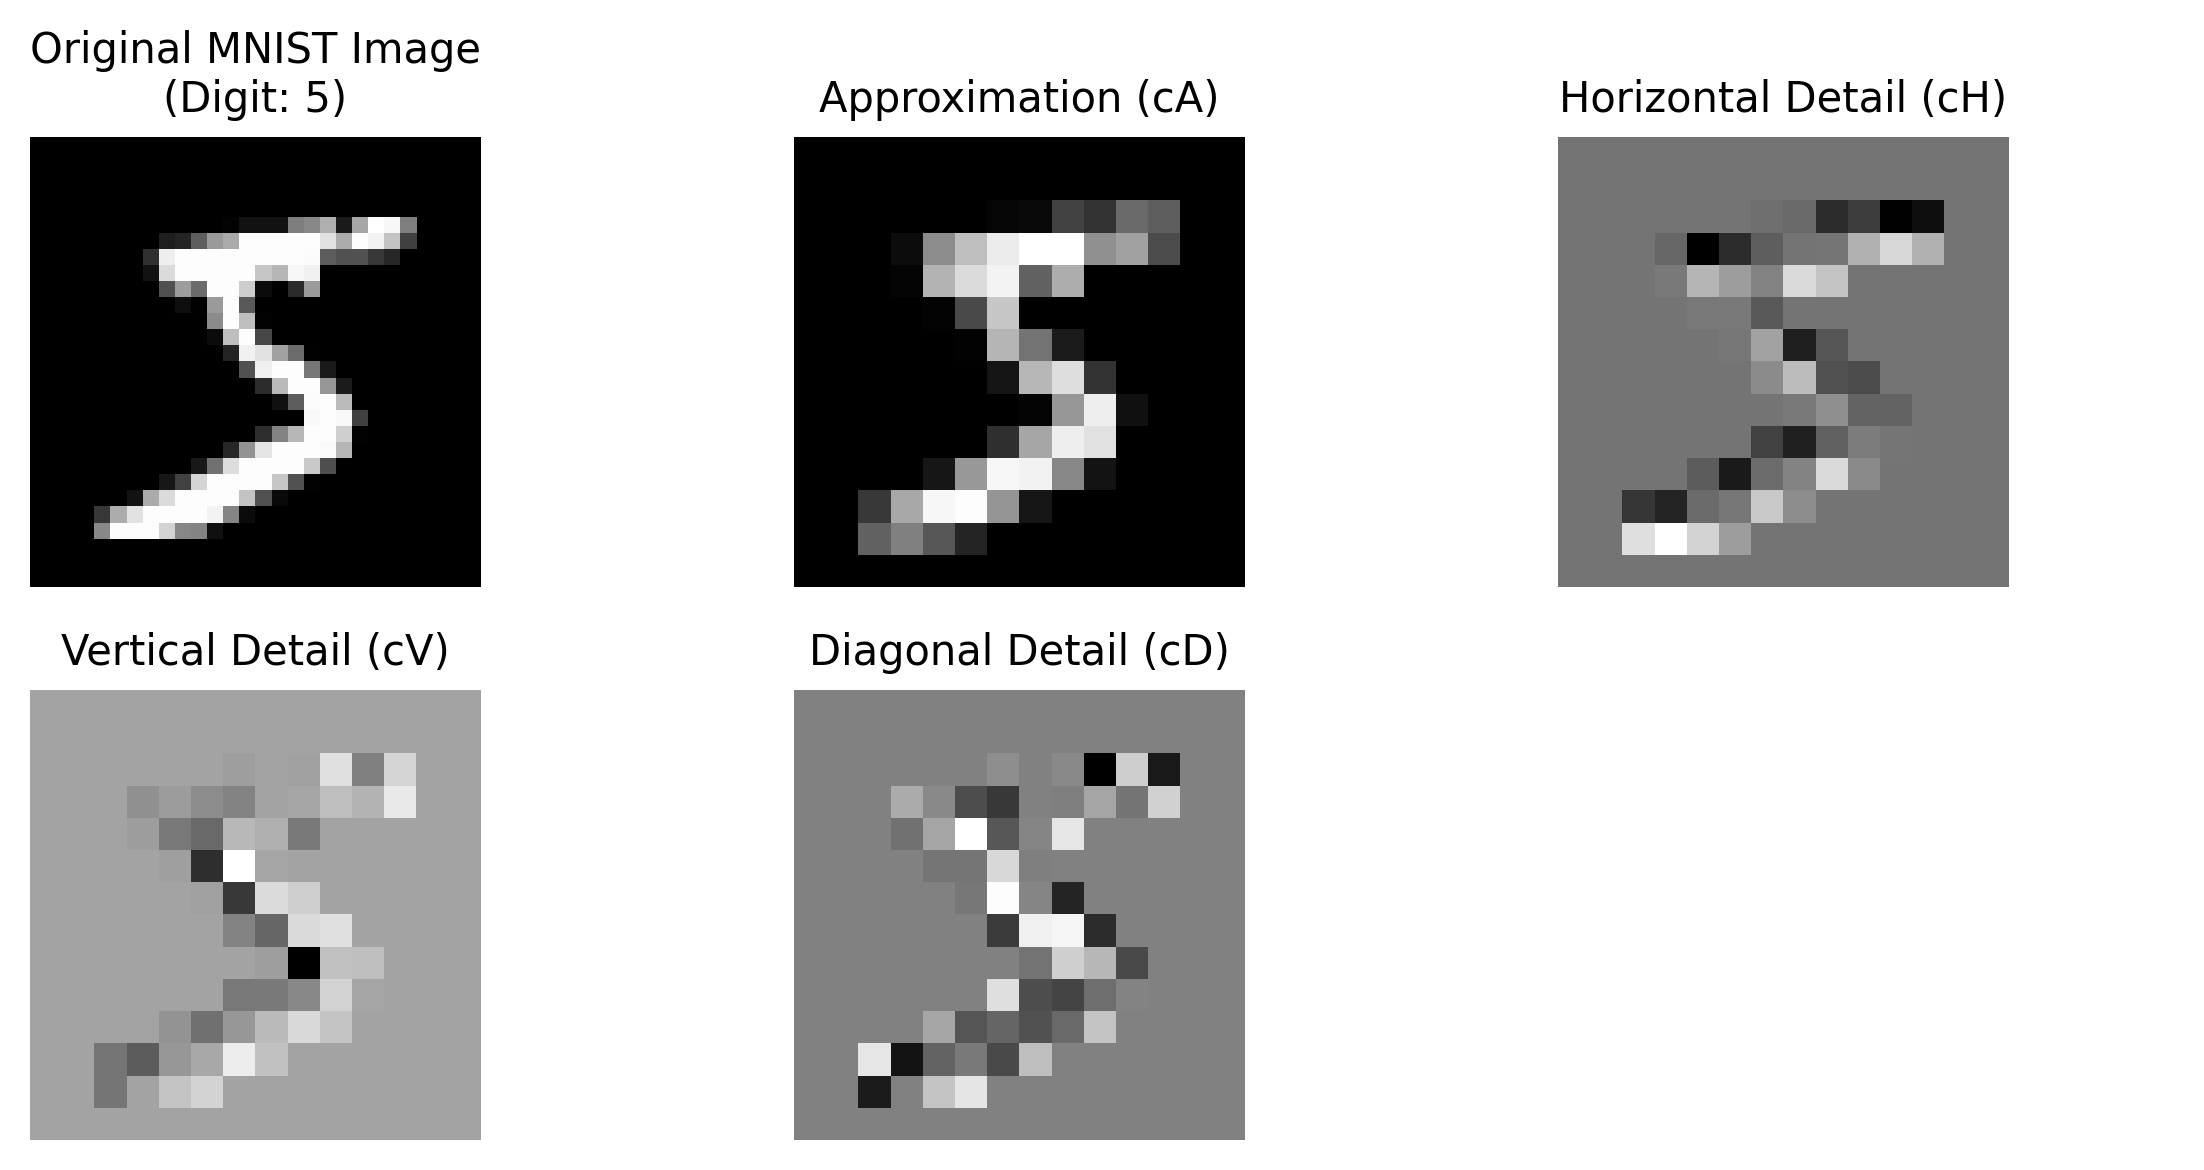

In [10]:
# Resize coefficients for visualization (optional for better visualization)
resize_dim = (14, 14)  # Resize to 14x14 for consistency
cA_resized = cv2.resize(cA, resize_dim, interpolation=cv2.INTER_LINEAR)
cH_resized = cv2.resize(cH, resize_dim, interpolation=cv2.INTER_LINEAR)
cV_resized = cv2.resize(cV, resize_dim, interpolation=cv2.INTER_LINEAR)
cD_resized = cv2.resize(cD, resize_dim, interpolation=cv2.INTER_LINEAR)

# Plot the original image and wavelet coefficients
plt.figure(figsize=(8, 4), dpi=300)

# 1. Original Image
plt.subplot(2, 3, 1)
plt.imshow(sample_img, cmap='gray')
plt.title(f"Original MNIST Image\n(Digit: 5)", fontsize=10)
plt.axis('off')

# 2. Approximation Coefficient (cA)
plt.subplot(2, 3, 2)
plt.imshow(cA_resized, cmap='gray')
plt.title('Approximation (cA)', fontsize=10)
plt.axis('off')

# 3. Horizontal Detail Coefficient (cH)
plt.subplot(2, 3, 3)
plt.imshow(cH_resized, cmap='gray')
plt.title('Horizontal Detail (cH)', fontsize=10)
plt.axis('off')

# 4. Vertical Detail Coefficient (cV)
plt.subplot(2, 3, 4)
plt.imshow(cV_resized, cmap='gray')
plt.title('Vertical Detail (cV)', fontsize=10)
plt.axis('off')

# 5. Diagonal Detail Coefficient (cD)
plt.subplot(2, 3, 5)
plt.imshow(cD_resized, cmap='gray')
plt.title('Diagonal Detail (cD)', fontsize=10)
plt.axis('off')

# Empty plot to balance grid
plt.subplot(2, 3, 6)
plt.axis('off')

# Adjust layout and display the figure
plt.tight_layout()

# Define the path where you want to save the figure
save_path = r"C:\Users\klnde\OneDrive\Desktop\Chandrasekhar Marseille\APL Computational Physics\Figures\wavelets.png"

# Save the figure
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Show the plots
plt.show()

### Wavelet

In [11]:
# Flatten spatial domain images
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Compute FFT and flatten
def compute_fft_features(images):
    fft_features = []
    for img in images:
        fft_img = fft2(img)
        fft_mag = np.log1p(np.abs(fftshift(fft_img)))  # Magnitude in log scale
        fft_phase = np.angle(fftshift(fft_img))  # Phase
        fft_combined = np.concatenate([fft_mag.flatten(), fft_phase.flatten()])
        fft_features.append(fft_combined)
    return np.array(fft_features)

X_train_fft = compute_fft_features(X_train)

# Compute Wavelet Features and Flatten
def compute_wavelet_features(images, wavelet='haar'):
    wavelet_features = []
    for img in images:
        coeffs2 = pywt.wavedec2(img, wavelet, level=1)
        cA, (cH, cV, cD) = coeffs2
        features = np.concatenate([cA.flatten(), cH.flatten(), cV.flatten(), cD.flatten()])
        wavelet_features.append(features)
    return np.array(wavelet_features)

X_train_wavelet = compute_wavelet_features(X_train)

In [12]:
# t-SNE for dimensionality reduction 
tsne_spatial = TSNE(n_components=2, random_state=42).fit_transform(X_train_flat[:2000])
tsne_fft = TSNE(n_components=2, random_state=42).fit_transform(X_train_fft[:2000])
tsne_wavelet = TSNE(n_components=2, random_state=42).fit_transform(X_train_wavelet[:2000])

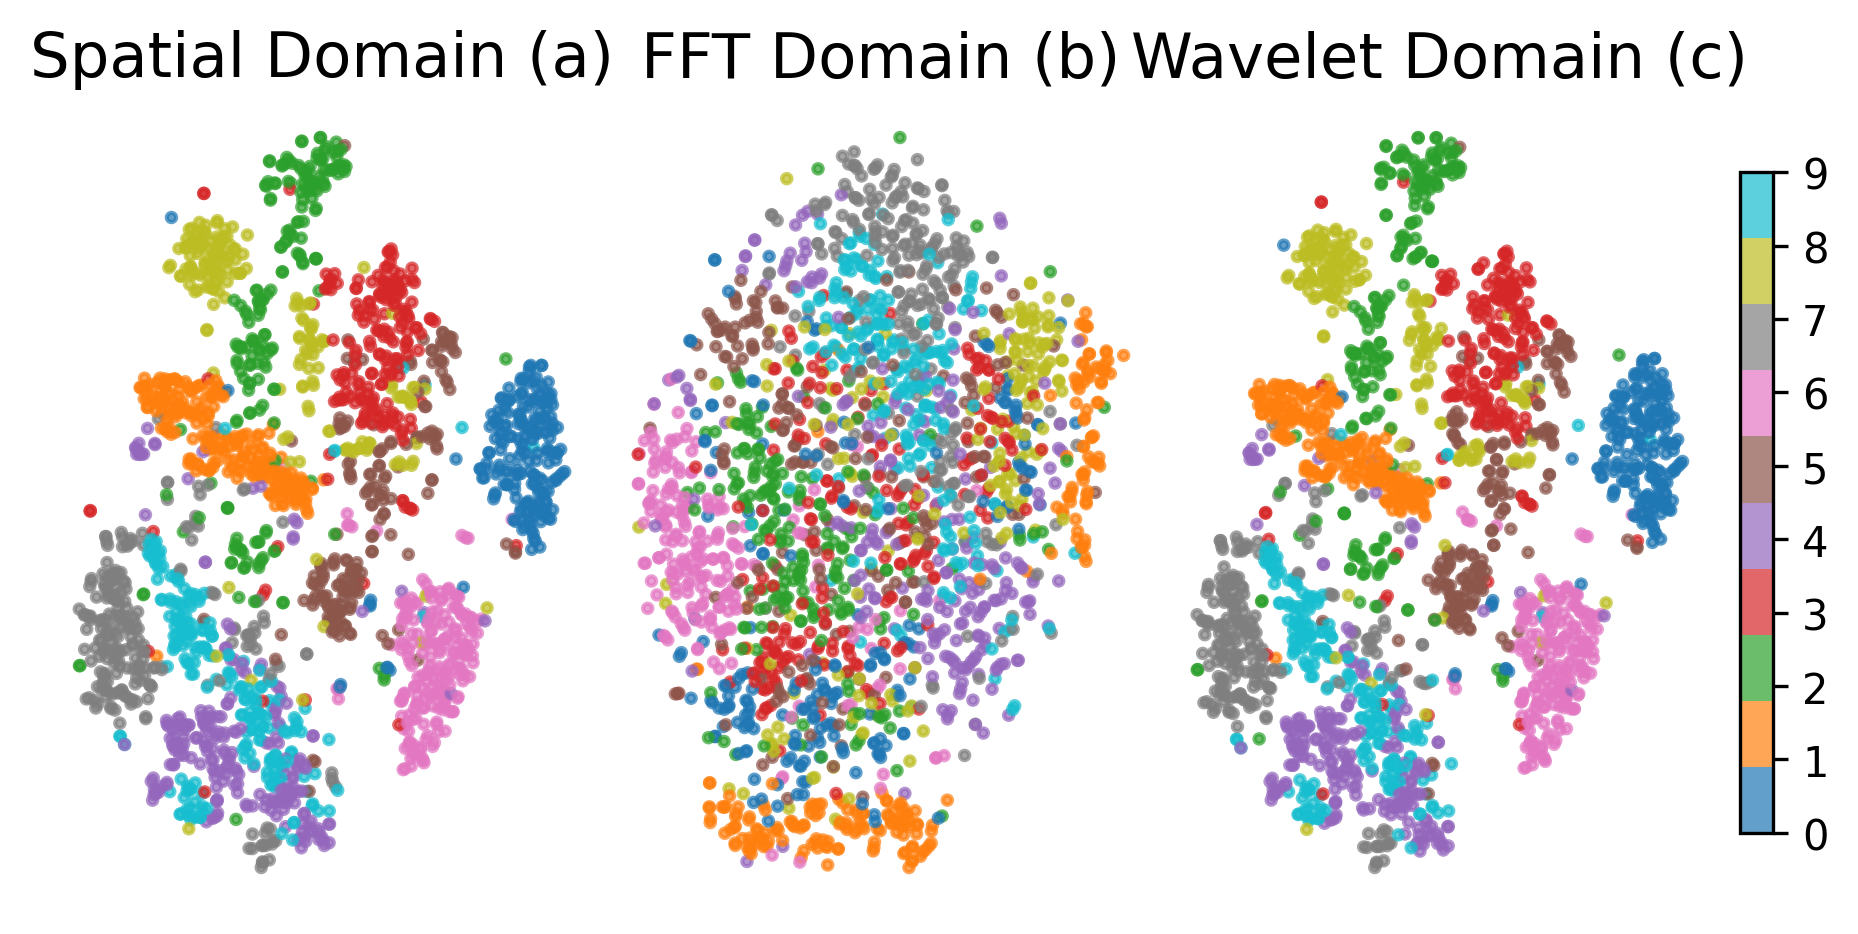

In [13]:
# Create a single figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(6, 3), dpi=300, constrained_layout=True)

# 1. Spatial Domain Plot
scatter1 = axes[0].scatter(tsne_spatial[:, 0], tsne_spatial[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[0].set_title("Spatial Domain (a)", fontsize=15)
axes[0].axis('off')

# 2. FFT Domain Plot
scatter2 = axes[1].scatter(tsne_fft[:, 0], tsne_fft[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[1].set_title("FFT Domain (b)", fontsize=15)
axes[1].axis('off')

# 3. Wavelet Domain Plot
scatter3 = axes[2].scatter(tsne_wavelet[:, 0], tsne_wavelet[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[2].set_title("Wavelet Domain (c)", fontsize=15)
axes[2].axis('off')

# Create a single colorbar for all plots
cbar = fig.colorbar(scatter3, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
#cbar.set_label("Digit Class", fontsize=15)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(range(10))

# Step 5: Save the figure to the specific folder
save_path = r"C:\Users\klnde\OneDrive\Desktop\Chandrasekhar Marseille\APL Computational Physics\Figures\tsne_class_separation.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Compute silhouette scores to quantify class separation
spatial_score = silhouette_score(X_train_flat[:2000], y_train[:2000])
fft_score = silhouette_score(X_train_fft[:2000], y_train[:2000])
wavelet_score = silhouette_score(X_train_wavelet[:2000], y_train[:2000])

print(f"Silhouette Score for Spatial Domain: {spatial_score:.4f}")
print(f"Silhouette Score for FFT Domain: {fft_score:.4f}")
print(f"Silhouette Score for Wavelet Domain: {wavelet_score:.4f}")

Silhouette Score for Spatial Domain: 0.0450
Silhouette Score for FFT Domain: 0.0027
Silhouette Score for Wavelet Domain: 0.0450


### PCA

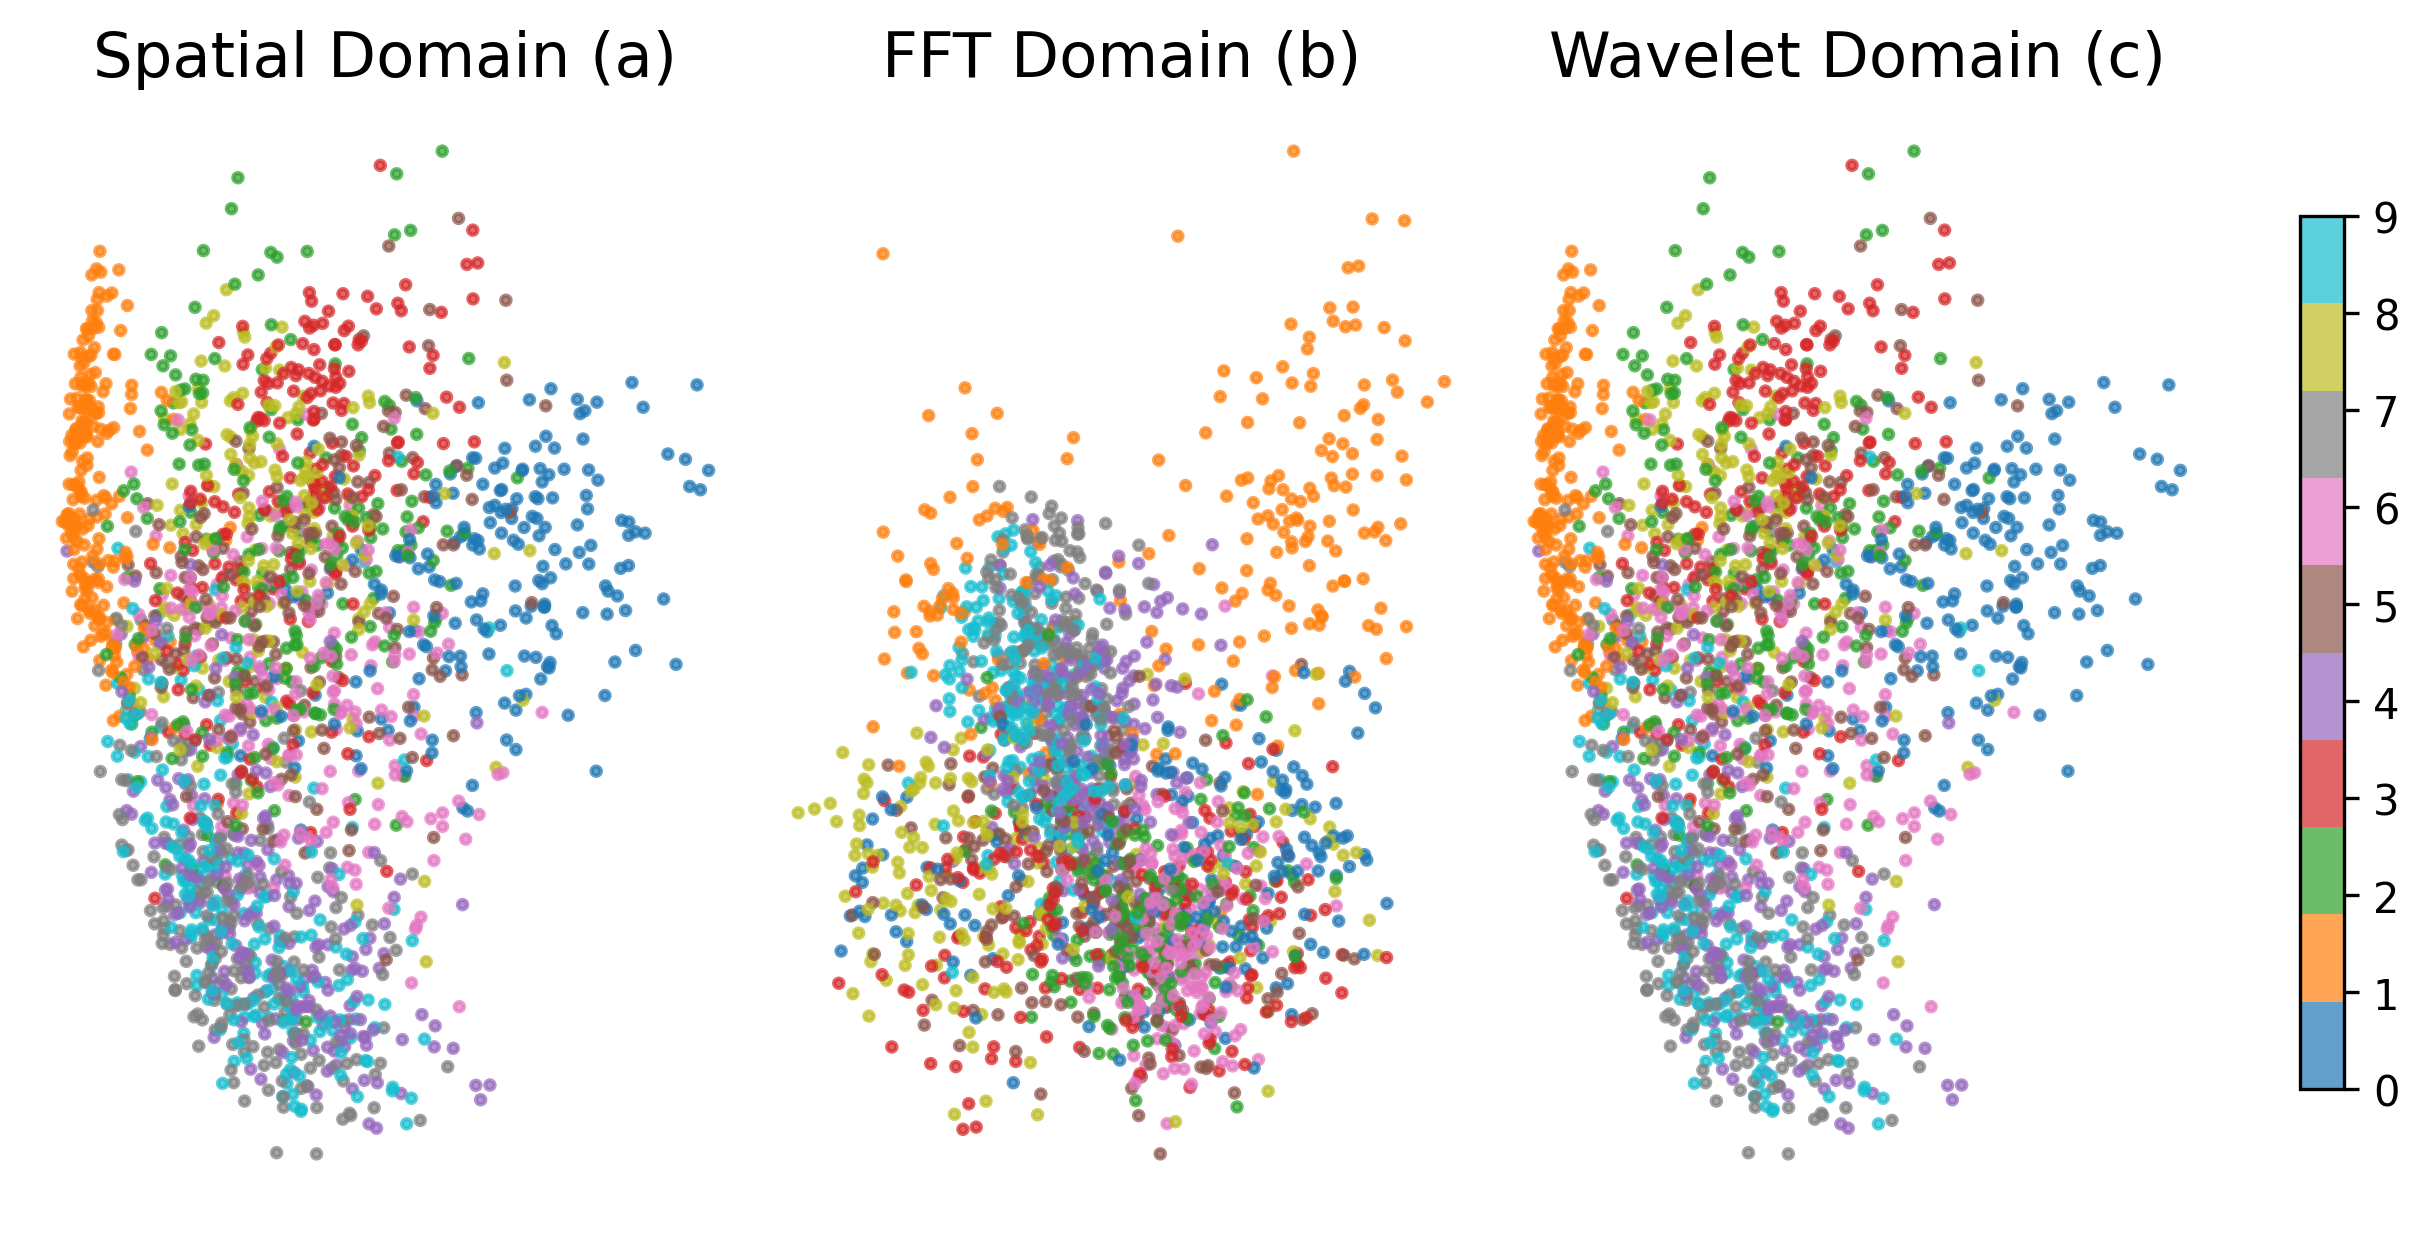

In [15]:
# Apply PCA for dimensionality reduction (use 2 components for 2D visualization)
pca_spatial = PCA(n_components=2).fit_transform(X_train_flat[:2000])
pca_fft = PCA(n_components=2).fit_transform(X_train_fft[:2000])
pca_wavelet = PCA(n_components=2).fit_transform(X_train_wavelet[:2000])

# Plot the PCA results
fig, axes = plt.subplots(1, 3, figsize=(8, 4), dpi=300, constrained_layout=True)

# 1. Spatial Domain PCA Plot
scatter1 = axes[0].scatter(pca_spatial[:, 0], pca_spatial[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[0].set_title("Spatial Domain (a)", fontsize=15)
axes[0].axis('off')

# 2. FFT Domain PCA Plot
scatter2 = axes[1].scatter(pca_fft[:, 0], pca_fft[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[1].set_title("FFT Domain (b)", fontsize=15)
axes[1].axis('off')

# 3. Wavelet Domain PCA Plot
scatter3 = axes[2].scatter(pca_wavelet[:, 0], pca_wavelet[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[2].set_title("Wavelet Domain (c)", fontsize=15)
axes[2].axis('off')

# Add the vertical color bar (scale) common to all three plots
cbar = fig.colorbar(scatter1, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
#cbar.set_label('Digit Label', fontsize=15)

# Step 5: Save the figure to the specific folder
save_path = r"C:\Users\klnde\OneDrive\Desktop\Chandrasekhar Marseille\APL Computational Physics\Figures\PCA_class_separation.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [16]:
score_spatial = silhouette_score(pca_spatial, y_train[:2000])
score_fft = silhouette_score(pca_fft, y_train[:2000])
score_wavelet = silhouette_score(pca_wavelet, y_train[:2000])

print("\nSeparability (Silhouette Scores after PCA reduction):")
print(f"Spatial Domain PCA Silhouette Score: {score_spatial:.3f}")
print(f"FFT Domain PCA Silhouette Score: {score_fft:.3f}")
print(f"Wavelet Domain PCA Silhouette Score: {score_wavelet:.3f}")


Separability (Silhouette Scores after PCA reduction):
Spatial Domain PCA Silhouette Score: 0.011
FFT Domain PCA Silhouette Score: -0.120
Wavelet Domain PCA Silhouette Score: 0.011


### Fashion MNIST

In [17]:
# Load Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Fashion MNIST dataset downloaded successfully!")

# Get path to the Fashion MNIST dataset
fashion_mnist_path = os.path.expanduser('~/.keras/datasets/fashion-mnist.npz')
print(f" Fashion MNIST dataset is stored at: {fashion_mnist_path}")

# Shape of the training and testing data
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

Fashion MNIST dataset downloaded successfully!
 Fashion MNIST dataset is stored at: C:\Users\klnde/.keras/datasets/fashion-mnist.npz
Training data shape: (60000, 28, 28), Training labels shape: (60000,)
Testing data shape: (10000, 28, 28), Testing labels shape: (10000,)


In [18]:
# Unique classes and their count
num_classes = len(np.unique(y_train))
print(f" Number of classes: {num_classes}")

 Number of classes: 10


In [19]:
# Class labels for Fashion MNIST
class_labels = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print("Fashion MNIST Class Labels:")
for i, label in enumerate(class_labels):
    print(f"{i}: {label}")
# Compute class distribution
train_class_counts = pd.Series(np.bincount(y_train), index=class_labels)
test_class_counts = pd.Series(np.bincount(y_test), index=class_labels)

Fashion MNIST Class Labels:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


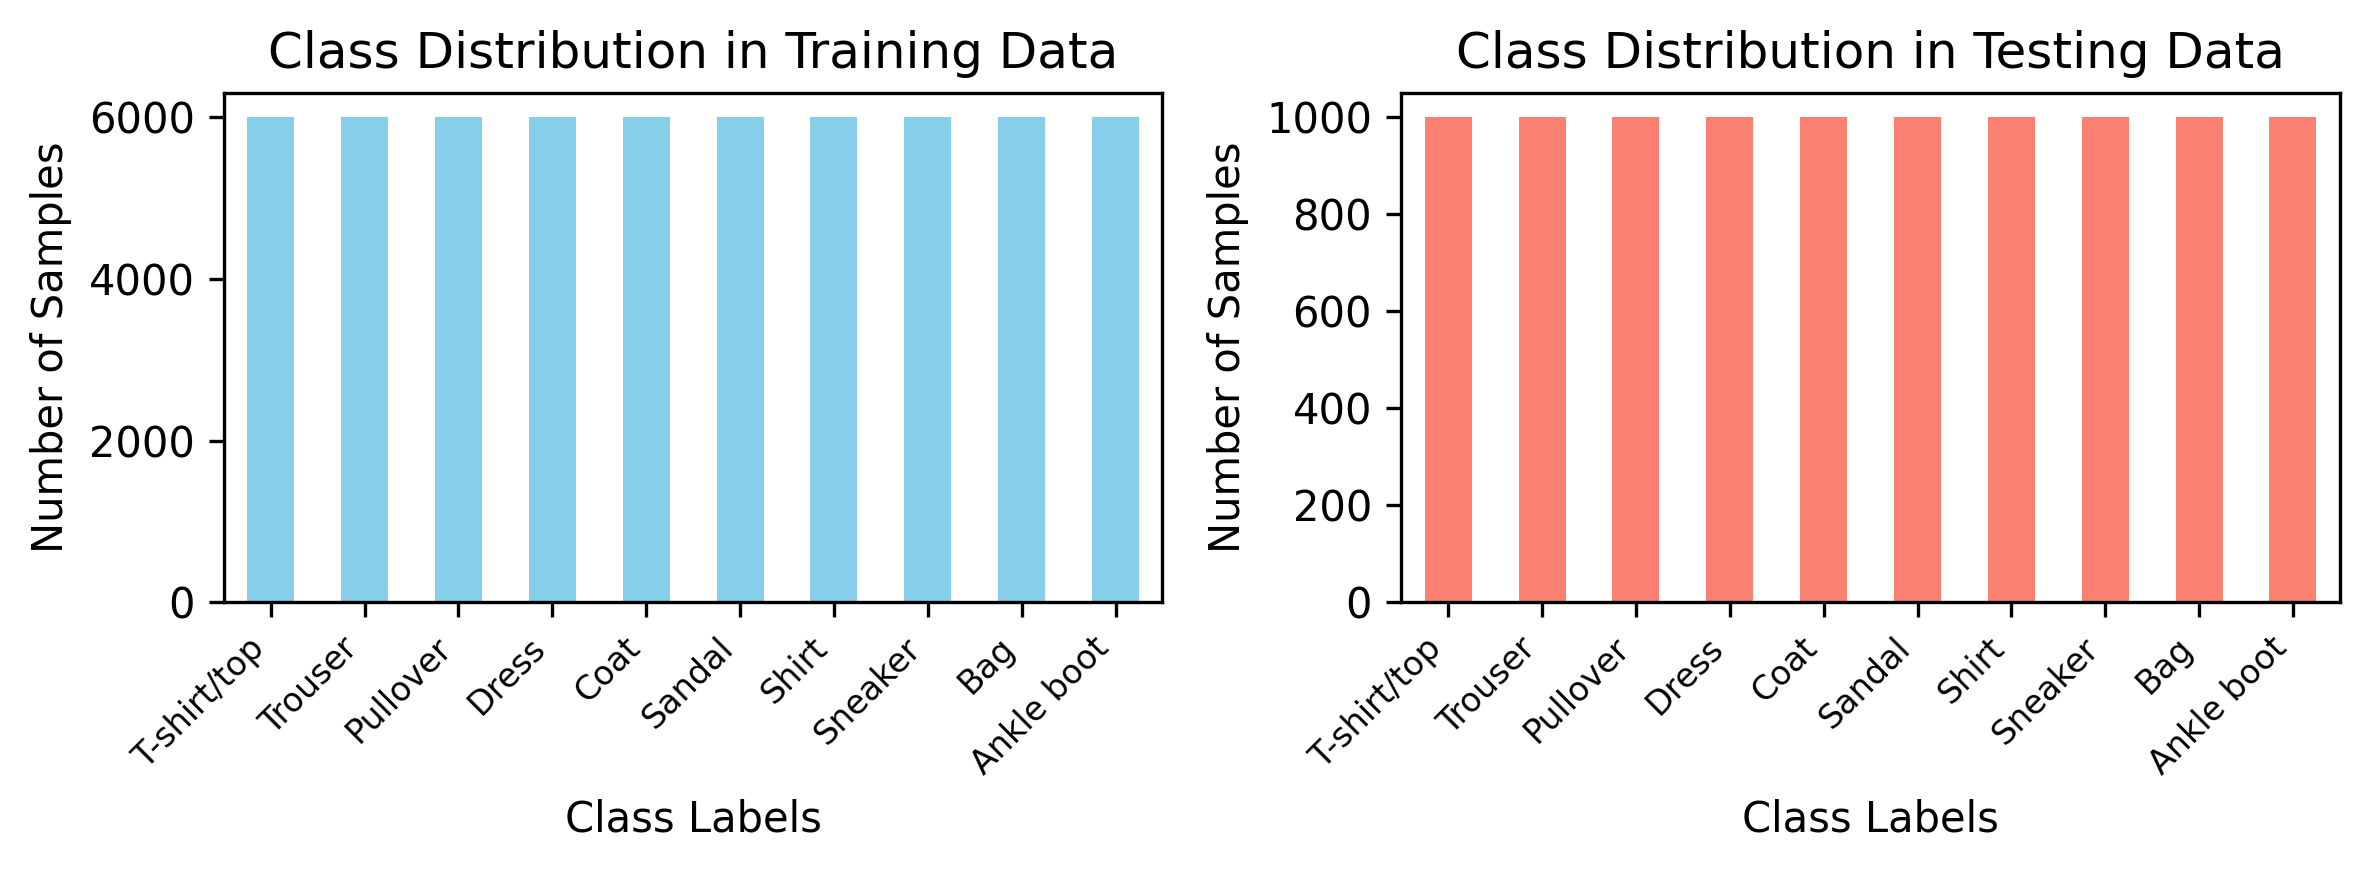

In [20]:
# Plot class distribution for training and testing data
plt.figure(figsize=(8, 3), dpi=300)

# 1. Plot training data distribution
plt.subplot(1, 2, 1)
train_class_counts.plot(kind='bar', color='skyblue')
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right', fontsize=8)

# 2. Plot testing data distribution
plt.subplot(1, 2, 2)
test_class_counts.plot(kind='bar', color='salmon')
plt.title('Class Distribution in Testing Data')
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right', fontsize=8)

# Improve layout and save high-resolution image
plt.tight_layout()

# Save the figure BEFORE showing it
plt.savefig("Fashion_MNIST_distribution.png", dpi=300, bbox_inches='tight')

# Show the plots
plt.show()

### Wavelet

In [21]:
# Flatten spatial domain images
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Compute FFT and flatten
def compute_fft_features(images):
    fft_features = []
    for img in images:
        fft_img = fft2(img)
        fft_mag = np.log1p(np.abs(fftshift(fft_img)))  # Magnitude in log scale
        fft_phase = np.angle(fftshift(fft_img))  # Phase
        fft_combined = np.concatenate([fft_mag.flatten(), fft_phase.flatten()])
        fft_features.append(fft_combined)
    return np.array(fft_features)

X_train_fft = compute_fft_features(X_train)

# Compute Wavelet Features and Flatten
def compute_wavelet_features(images, wavelet='haar'):
    wavelet_features = []
    for img in images:
        coeffs2 = pywt.wavedec2(img, wavelet, level=1)
        cA, (cH, cV, cD) = coeffs2
        features = np.concatenate([cA.flatten(), cH.flatten(), cV.flatten(), cD.flatten()])
        wavelet_features.append(features)
    return np.array(wavelet_features)

X_train_wavelet = compute_wavelet_features(X_train)

# Apply t-SNE for dimensionality reduction (optional: use PCA for faster results)
tsne_spatial = TSNE(n_components=2, random_state=42).fit_transform(X_train_flat[:2000])
tsne_fft = TSNE(n_components=2, random_state=42).fit_transform(X_train_fft[:2000])
tsne_wavelet = TSNE(n_components=2, random_state=42).fit_transform(X_train_wavelet[:2000])

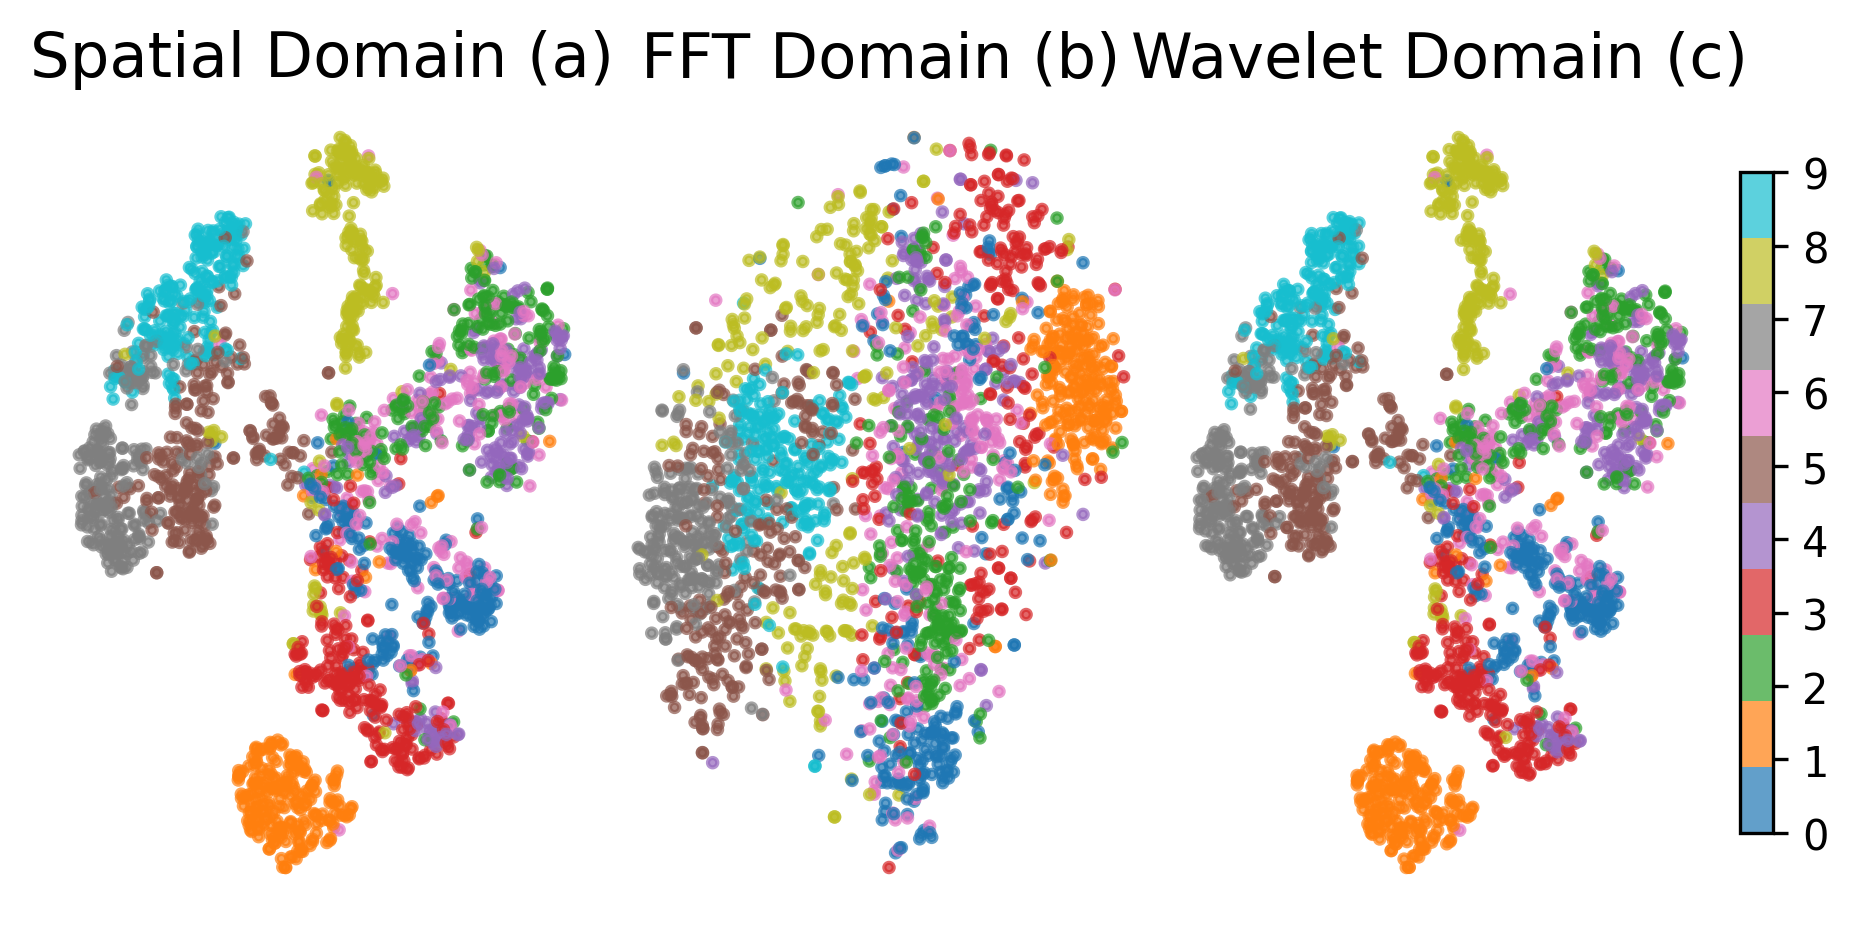

In [22]:
# Create a single figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(6, 3), dpi=300, constrained_layout=True)

# 1. Spatial Domain Plot
scatter1 = axes[0].scatter(tsne_spatial[:, 0], tsne_spatial[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[0].set_title("Spatial Domain (a)", fontsize=15)
axes[0].axis('off')

# 2. FFT Domain Plot
scatter2 = axes[1].scatter(tsne_fft[:, 0], tsne_fft[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[1].set_title("FFT Domain (b)", fontsize=15)
axes[1].axis('off')

# 3. Wavelet Domain Plot
scatter3 = axes[2].scatter(tsne_wavelet[:, 0], tsne_wavelet[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[2].set_title("Wavelet Domain (c)", fontsize=15)
axes[2].axis('off')

# Create a single colorbar for all plots
cbar = fig.colorbar(scatter3, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
#cbar.set_label("Digit Class", fontsize=15)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(range(10))

# Step 5: Save the figure to the specific folder
save_path = r"C:\Users\klnde\OneDrive\Desktop\Chandrasekhar Marseille\APL Computational Physics\Figures\tsne_class_separation_fashion_mnist.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Compute silhouette scores to quantify class separation
spatial_score = silhouette_score(X_train_flat[:2000], y_train[:2000])
fft_score = silhouette_score(X_train_fft[:2000], y_train[:2000])
wavelet_score = silhouette_score(X_train_wavelet[:2000], y_train[:2000])

print(f"Silhouette Score for Spatial Domain: {spatial_score:.4f}")
print(f"Silhouette Score for FFT Domain: {fft_score:.4f}")
print(f"Silhouette Score for Wavelet Domain: {wavelet_score:.4f}")

Silhouette Score for Spatial Domain: 0.0520
Silhouette Score for FFT Domain: 0.0087
Silhouette Score for Wavelet Domain: 0.0520


### PCA

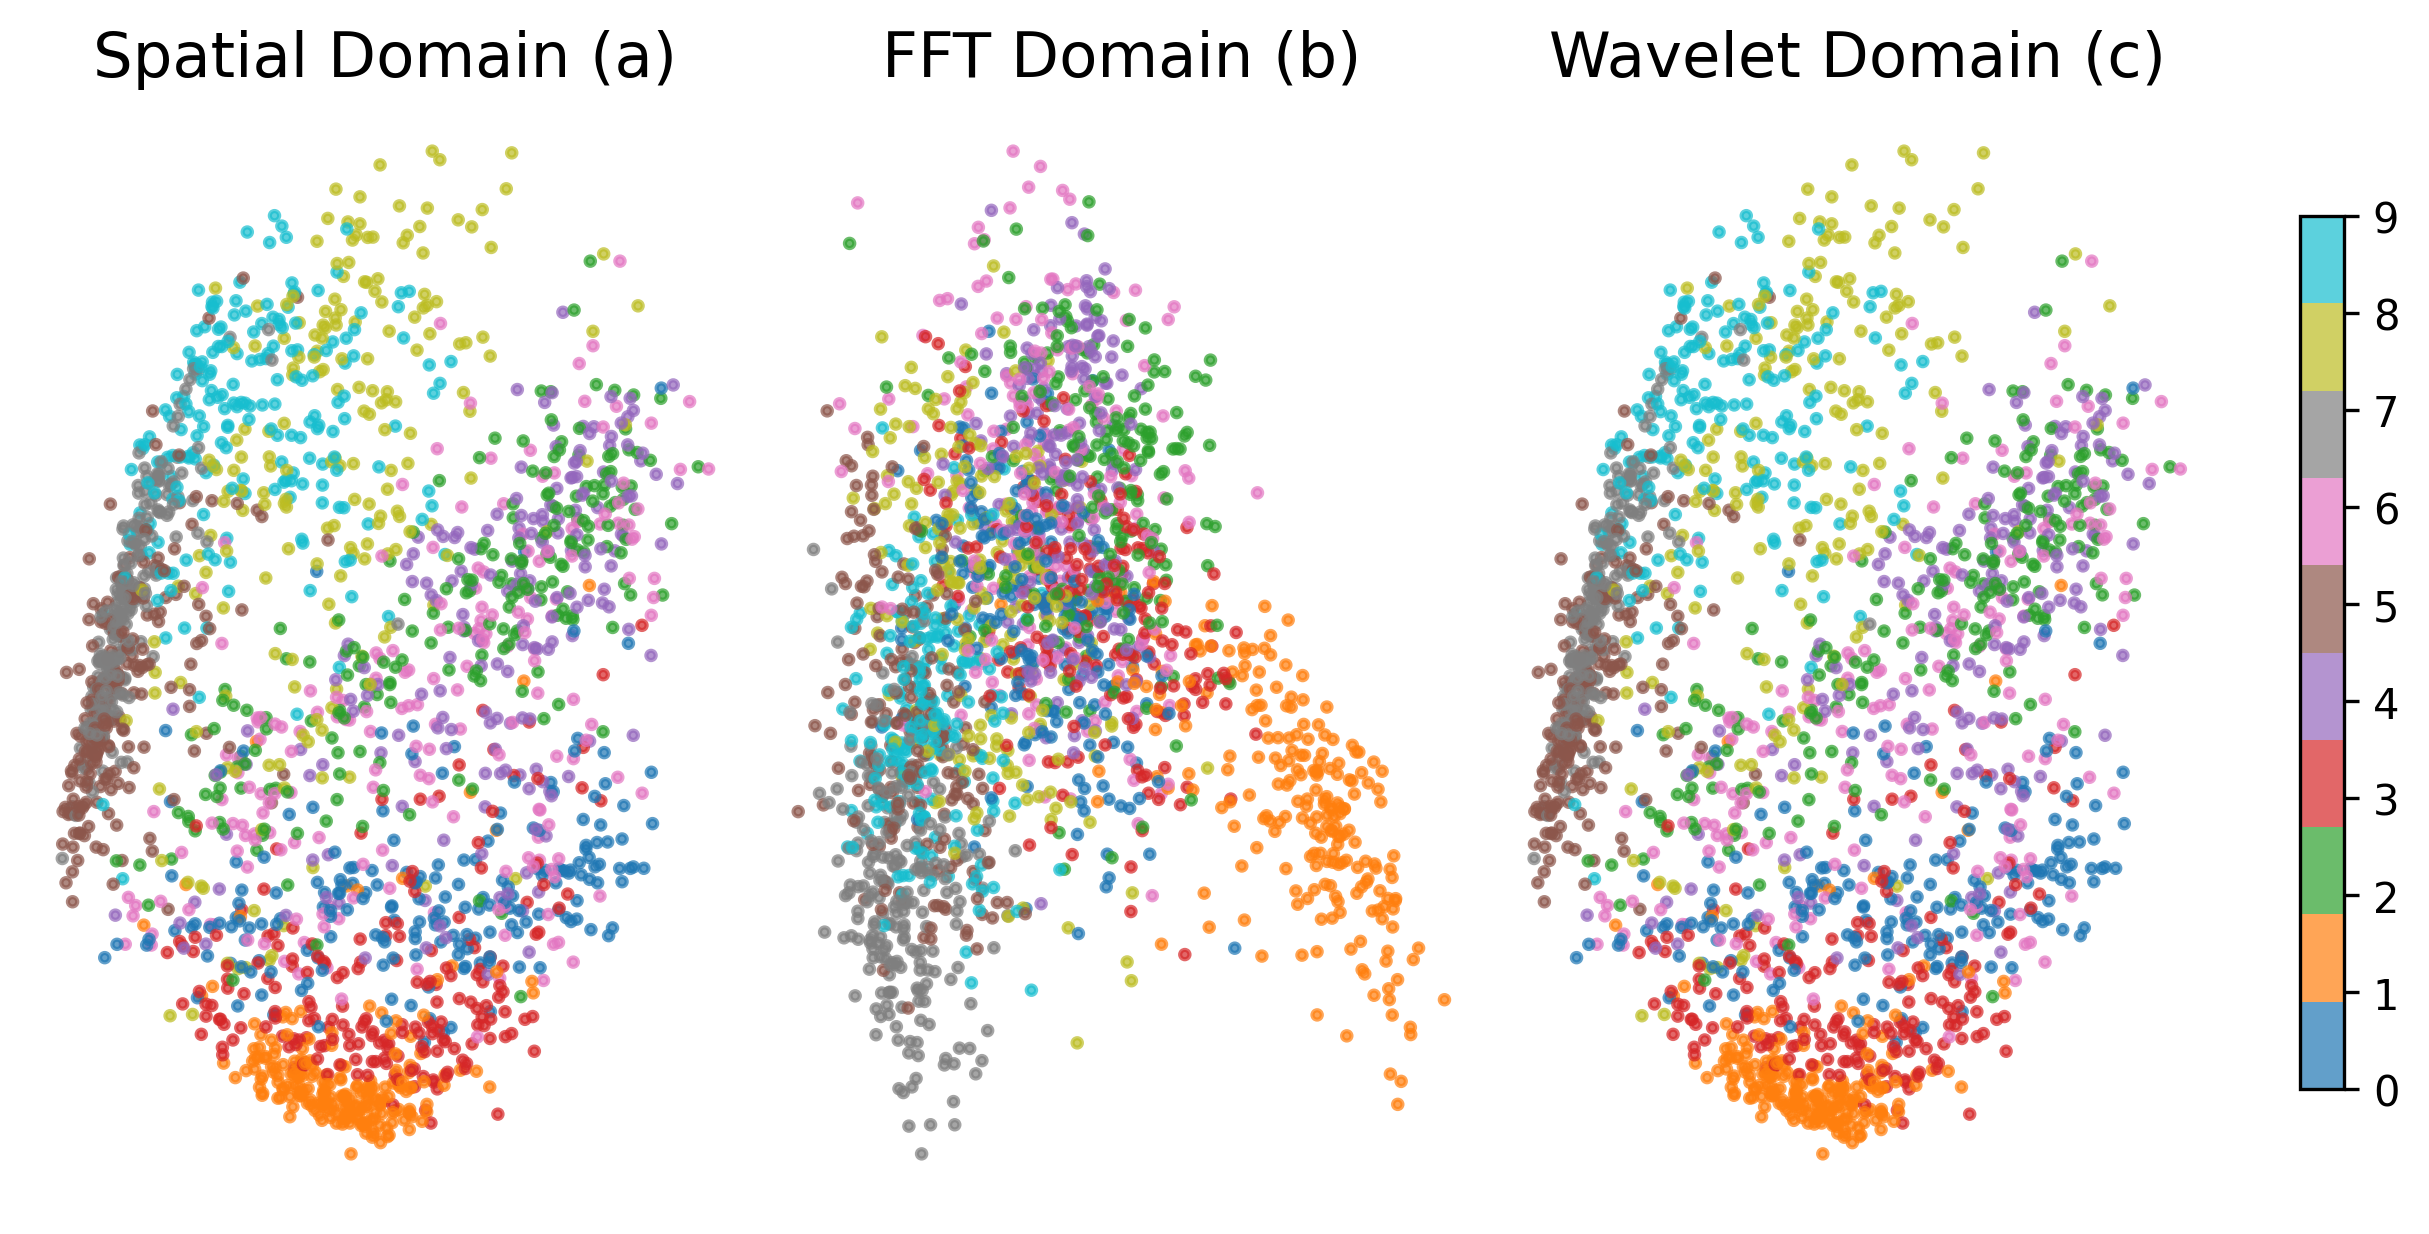

In [25]:
# Apply PCA for dimensionality reduction (use 2 components for 2D visualization)
pca_spatial = PCA(n_components=2).fit_transform(X_train_flat[:2000])
pca_fft = PCA(n_components=2).fit_transform(X_train_fft[:2000])
pca_wavelet = PCA(n_components=2).fit_transform(X_train_wavelet[:2000])

# Plot the PCA results
fig, axes = plt.subplots(1, 3, figsize=(8, 4), dpi=300, constrained_layout=True)

# 1. Spatial Domain PCA Plot
scatter1 = axes[0].scatter(pca_spatial[:, 0], pca_spatial[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[0].set_title("Spatial Domain (a)", fontsize=15)
axes[0].axis('off')

# 2. FFT Domain PCA Plot
scatter2 = axes[1].scatter(pca_fft[:, 0], pca_fft[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[1].set_title("FFT Domain (b)", fontsize=15)
axes[1].axis('off')

# 3. Wavelet Domain PCA Plot
scatter3 = axes[2].scatter(pca_wavelet[:, 0], pca_wavelet[:, 1], c=y_train[:2000], cmap='tab10', s=5, alpha=0.7)
axes[2].set_title("Wavelet Domain (c)", fontsize=15)
axes[2].axis('off')

# Add the vertical color bar (scale) common to all three plots
cbar = fig.colorbar(scatter1, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
#cbar.set_label('Digit Label', fontsize=15)

# Step 5: Save the figure to the specific folder
save_path = r"C:\Users\klnde\OneDrive\Desktop\Chandrasekhar Marseille\APL Computational Physics\Figures\PCA_class_separation_fashion_mnist.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [26]:
score_spatial = silhouette_score(pca_spatial, y_train[:2000])
score_fft = silhouette_score(pca_fft, y_train[:2000])
score_wavelet = silhouette_score(pca_wavelet, y_train[:2000])

print("\nSeparability (Silhouette Scores after PCA reduction):")
print(f"Spatial Domain PCA Silhouette Score: {score_spatial:.3f}")
print(f"FFT Domain PCA Silhouette Score: {score_fft:.3f}")
print(f"Wavelet Domain PCA Silhouette Score: {score_wavelet:.3f}")


Separability (Silhouette Scores after PCA reduction):
Spatial Domain PCA Silhouette Score: -0.027
FFT Domain PCA Silhouette Score: 0.001
Wavelet Domain PCA Silhouette Score: -0.027
